In [22]:
from tqdm import tqdm
from torchinfo import summary
import matplotlib.pyplot as plt
import data_proc.data_preproc as data_preproc
import dino.dino_features as features
import numpy as np

In [1]:
import torch

In [4]:
print(torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch cuda version:", torch.version.cuda)
print("compiled with cuda:", torch.backends.cuda.is_built())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

2.10.0+cu130
cuda available: True
torch cuda version: 13.0
compiled with cuda: True
device: cuda


# Data

In [12]:
img_net_loader, img_net_loader_val = data_preproc.get_dataloaders(data = "tiny_imagenet")

cuda


In [13]:
eruo_sat_loader, eruo_sat_loader_val = data_preproc.get_dataloaders(data = "eurosat_rgb")

In [63]:
uc_merced_loader, uc_merced_loader_val = data_preproc.get_dataloaders(data = "uc_merced")

In [6]:
eddy_loader, eddy_loader_val = data_preproc.get_dataloaders(data = "eddy")

torch.Size([64, 3, 224, 224])
shape: torch.Size([64, 3, 224, 224])
dtype: torch.float32
device: cpu
min: -4.269491195678711
max: 61.48038101196289
nan count: 0
inf count: 0


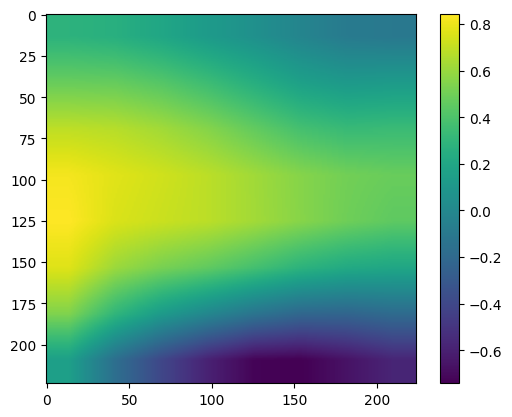

In [7]:
for batch in eddy_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[0][2]

    plt.imshow(img)
    plt.colorbar()

    images = batch["image"]
    print("shape:", images.shape)
    print("dtype:", images.dtype)
    print("device:", images.device)
    print("min:", images.min().item())
    print("max:", images.max().item())
    print("nan count:", torch.isnan(images).sum().item())
    print("inf count:", torch.isinf(images).sum().item())
    break

torch.Size([64, 3, 224, 224])


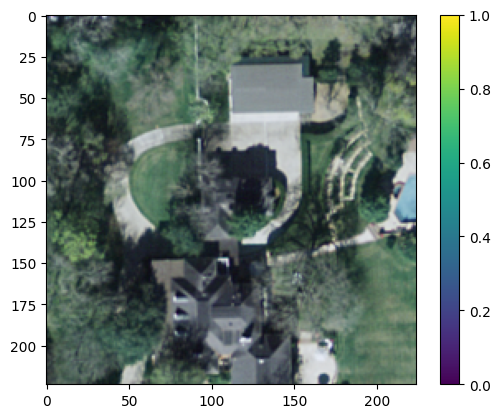

In [15]:
for batch in uc_merced_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

torch.Size([64, 3, 224, 224])


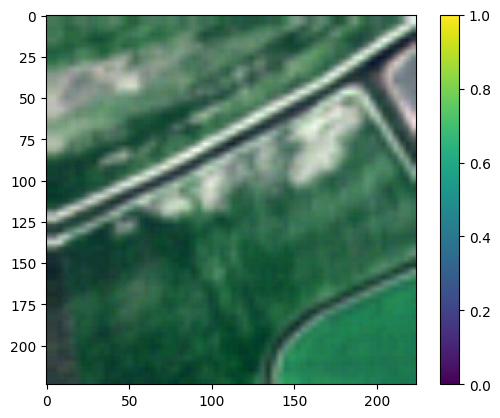

In [16]:
for batch in eruo_sat_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break


torch.Size([64, 3, 224, 224])


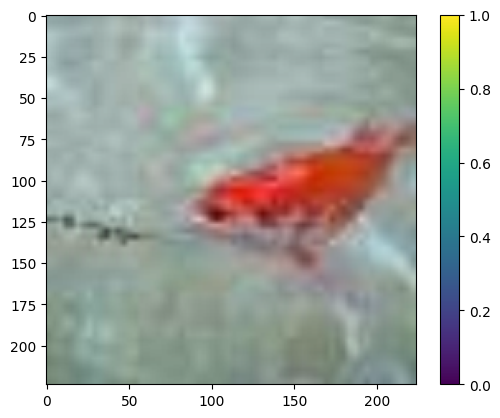

In [17]:
for batch in img_net_loader_val:

    images = batch["image"]
    labels = batch["label"]
    print(images.shape)

    img = images[1].permute(1, 2, 0)#.cpu()

    img = (img - img.min()) / (img.max() - img.min())

    plt.imshow(img)
    plt.colorbar()
    break

# Features

In [2]:
model = torch.hub.load('facebookresearch/dino:main', 'dino_vits8')
model.eval()
model.to("cuda")

Using cache found in /home/jovyan/.cache/torch/hub/facebookresearch_dino_main


VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(8, 8), stride=(8, 8))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
  (head): Identity()
)

In [18]:
subsample_percent = 10
model.eval().to(device)

X_tiny_image_net, y_tiny_image_net = features.frozen_features(model, img_net_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_tiny_image_net, y_val_tiny_image_net = features.frozen_features(model, img_net_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 1563/1563 [14:18<00:00,  1.82it/s]


torch.Size([100000, 384]) torch.Size([100000])



100%|██████████| 157/157 [01:24<00:00,  1.85it/s]

torch.Size([10000, 384]) torch.Size([10000])


In [41]:
subsample_percent = 10
model.eval().to(device)

X_eruosat_rgb, y_eruosat_rgb = features.frozen_features(model, eruo_sat_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_eruosat_rgb, y_val_eruosat_rgb = features.frozen_features(model, eruo_sat_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 254/254 [02:25<00:00,  1.74it/s]


torch.Size([16200, 384]) torch.Size([16200])



100%|██████████| 85/85 [00:46<00:00,  1.83it/s]

torch.Size([5400, 384]) torch.Size([5400])


In [64]:
subsample_percent = 10
model.eval().to(device)

X_uc_merced, y_uc_merced = features.frozen_features(model, uc_merced_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_uc_merced, y_val_uc_merced = features.frozen_features(model, uc_merced_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 27/27 [04:16<00:00,  9.51s/it]


torch.Size([1680, 384]) torch.Size([1680])



100%|██████████| 7/7 [00:22<00:00,  3.19s/it]

torch.Size([420, 384]) torch.Size([420])


In [8]:
subsample_percent = 10
model.eval().to(device)

X_eddy, y_eddy = features.frozen_features(model, eddy_loader, device, subsample_percent=None, data_type="tiny_image_net")
X_val_eddy, y_val_eddy = features.frozen_features(model, eddy_loader_val, device, subsample_percent=None, data_type="tiny_image_net")

100%|██████████| 61/61 [02:37<00:00,  2.59s/it]


torch.Size([3892, 384]) torch.Size([3892])



100%|██████████| 15/15 [00:24<00:00,  1.66s/it]

torch.Size([950, 384]) torch.Size([950])


# Zero Shot

In [10]:
from sklearn.neighbors import KNeighborsClassifier

def knn_score(X, y, X_val, y_val, k=5):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X, y)

    print(neigh.score(X_val, y_val))

In [20]:
knn_score(X_tiny_image_net, y_tiny_image_net, X_val_tiny_image_net, y_val_tiny_image_net, k=5)

0.7655


In [42]:
knn_score(X_eruosat_rgb, y_eruosat_rgb, X_val_eruosat_rgb, y_val_eruosat_rgb, k=5)

0.9540740740740741


In [65]:
knn_score(X_uc_merced, y_uc_merced, X_val_uc_merced, y_val_uc_merced, k=5)

0.9404761904761905


In [11]:
knn_score(X_eddy, y_eddy, X_val_eddy, y_val_eddy, k=5)

0.6368421052631579


# Clustering

In [24]:
from sklearn.cluster import KMeans

def run_kmeans_and_count(X, y, seed=42):
    n_classes = len(np.unique(y))
    kmeans = KMeans(n_clusters=n_classes, random_state=seed, n_init=10)
    clusters = kmeans.fit_predict(X)

    counts = np.zeros((n_classes, n_classes), dtype=int)
    for c, label in zip(clusters, y):
        counts[c, label] += 1

    return clusters, counts, kmeans

In [32]:
np.unique(y_val_tiny_image_net)

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [28]:
X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)

clusters, counts, kmeans = run_kmeans_and_count(X_val_tiny_image_net_norm, y_val_tiny_image_net)

print("cluster assignments shape:", clusters.shape)
print("counts:")
print(counts)

/tmp/ipykernel_190/3063479091.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)


cluster assignments shape: (10000,)
counts:
[[0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 1 0 ... 0 1 1]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [79]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap.umap_ as umap

def vis_dim_redux(X, labels, class_subset=None, label_title="class", dims=2, redux="pca"):

    if class_subset is not None:
        rng = np.random.default_rng(42)
        
        classes = np.unique(labels)
        chosen = rng.choice(classes, size=class_subset, replace=False)
    
        idxs = []
        for c in chosen:
            c_idx = np.where(labels == c)[0]
            take = len(c_idx)
            idxs.extend(rng.choice(c_idx, size=take, replace=False))
    
        idxs = np.array(idxs)
        X = X[idxs]
        labels = labels[idxs]
        
    if redux == "pca":
        pca = PCA(n_components=dims)
        X_d = pca.fit_transform(X) 
    
    elif redux == "umap":
        reducer = umap.UMAP(n_components=dims) #, random_state=42)
        X_d = reducer.fit_transform(X)
        

    labels = labels

    if dims ==2:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111)
    
        scatter = ax.scatter(
            X_d[:,0],
            X_d[:,1],
            c=labels,
            cmap="tab10",
            s=10
        )
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

    if dims == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')
    
        scatter = ax.scatter(
            X_d[:,0],
            X_d[:,1],
            X_d[:,2],
            c=labels,
            cmap="tab10",
            s=10
        )
    
        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
        ax.set_zlabel("C3")
    
        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

plt.show()

# Imagenet

In [71]:
X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)

img_clusters, img_counts, img_kmeans = run_kmeans_and_count(X_val_tiny_image_net_norm, y_val_tiny_image_net)

/tmp/ipykernel_190/664894505.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_val_tiny_image_net_norm = X_val_tiny_image_net / np.linalg.norm(X_val_tiny_image_net, axis=1, keepdims=True)


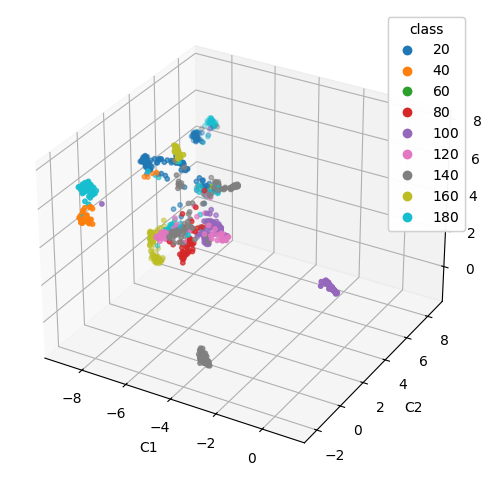

In [82]:
vis_dim_redux(X_val_tiny_image_net, y_val_tiny_image_net, dims=3, redux="umap", class_subset=20)

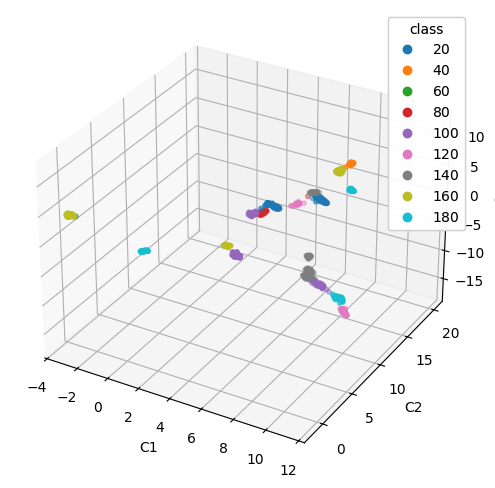

In [85]:
vis_dim_redux(X_val_tiny_image_net, img_kmeans.labels_, class_subset=20, redux="umap", dims=3)

# Eurosat

In [44]:
X_val_eruosat_rgb_norm = X_val_eruosat_rgb / np.linalg.norm(X_val_eruosat_rgb, axis=1, keepdims=True)

eruosat_clusters, eurosat_counts, eurosat_kmeans = run_kmeans_and_count(X_val_eruosat_rgb_norm, y_val_eruosat_rgb)

print("cluster assignments shape:", clusters.shape)
print("counts:")
print(counts)

/tmp/ipykernel_190/2848573864.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_val_eruosat_rgb_norm = X_val_eruosat_rgb / np.linalg.norm(X_val_eruosat_rgb, axis=1, keepdims=True)


cluster assignments shape: (3892,)
counts:
[[644 487 560]
 [402 342 409]
 [439 316 293]]


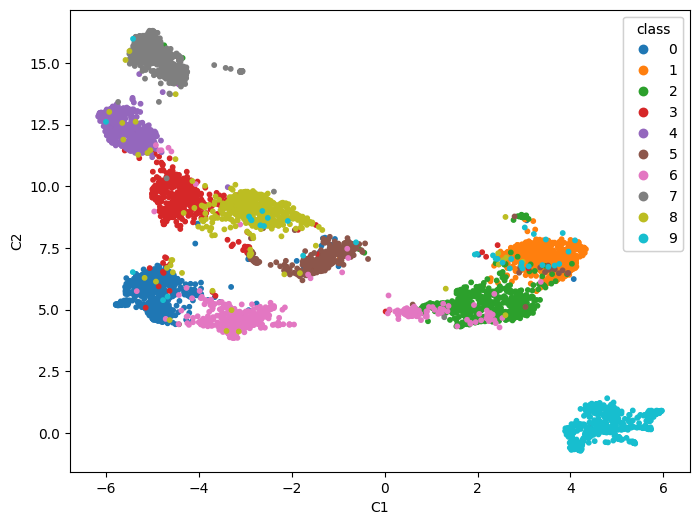

In [73]:
vis_dim_redux(X_val_eruosat_rgb, y_val_eruosat_rgb, redux="umap")

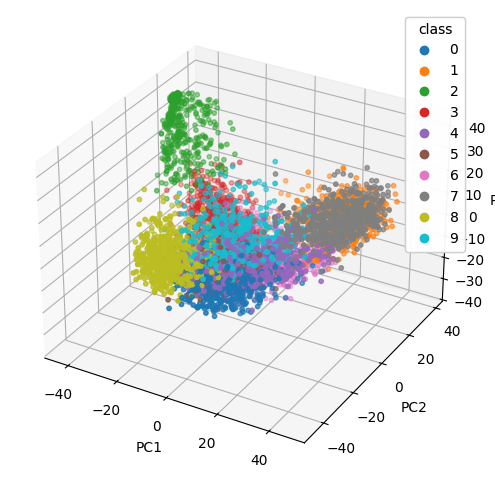

In [61]:
vis_dim_redux(X_val_eruosat_rgb, eurosat_kmeans.labels_, dims=3)

# EDDY

In [52]:
X_eddy_norm = X_eddy / np.linalg.norm(X_eddy, axis=1, keepdims=True)

eddy_clusters, eddy_counts, eddy_kmeans = run_kmeans_and_count(X_eddy_norm, y_eddy)

print("cluster assignments shape:", clusters.shape)
print("counts:")
print(counts)

/tmp/ipykernel_190/551244219.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  X_eddy_norm = X_eddy / np.linalg.norm(X_eddy, axis=1, keepdims=True)


cluster assignments shape: (3892,)
counts:
[[644 487 560]
 [402 342 409]
 [439 316 293]]


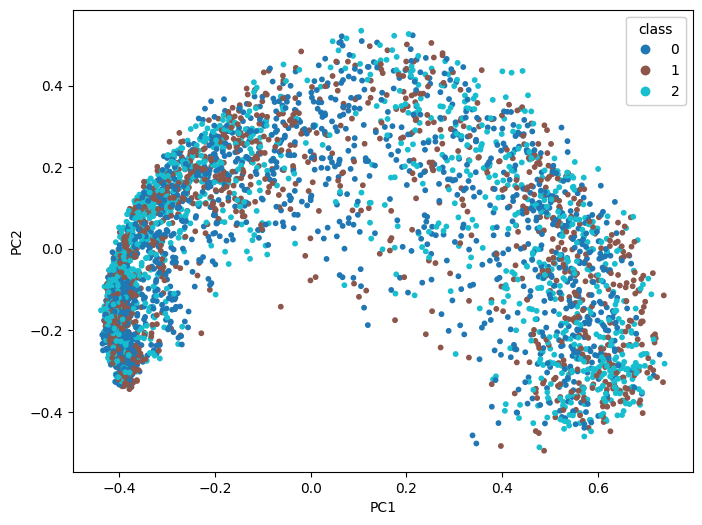

In [50]:
vis_dim_redux(X_eddy_norm, y_eddy)

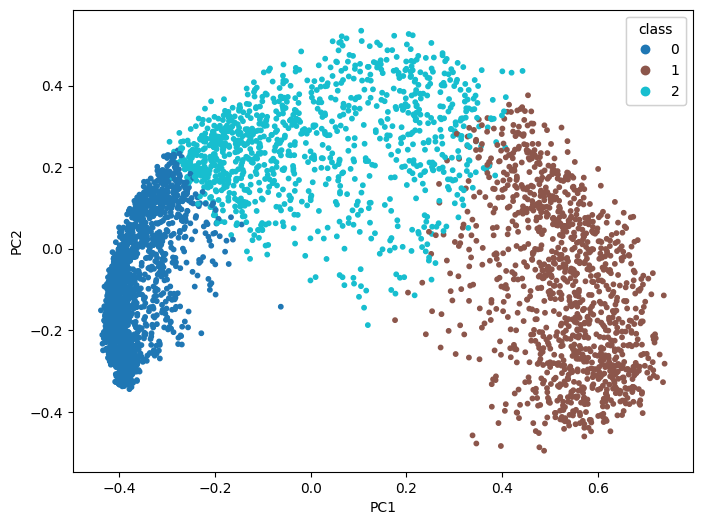

In [54]:
vis_dim_redux(X_eddy_norm, eddy_kmeans.labels_)